# A-Level Advanced Deep Learning Project: Flickr8k Image Captioning

This single notebook combines Week 1, Week 2, Week 3 and Week 4 into one complete project.

**Problem:** generate a natural language caption for an uploaded image.

**Final output:** trained CNN-LSTM image captioning model + Streamlit app.

## 0. Setup
Run this notebook in Google Colab. For faster training, use **Runtime → Change runtime type → GPU**.

In [1]:
!pip install kaggle nltk scikit-learn matplotlib streamlit -q

import os, re, string, random, json
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 125.5 MB/s eta 0:00:00
Device: cuda


## 1. Load Flickr8k dataset from Kaggle

Use one of these options:

1. **Recommended:** set Kaggle API token using environment variables.
2. Or upload `kaggle.json` to Colab.

Do not upload large `Images.zip` manually; downloading from Kaggle is faster.

In [2]:
os.environ['KAGGLE_USERNAME'] = 'Ayanat Kanat'
os.environ['KAGGLE_KEY'] = 'KGAT_ba09b76bb3e3c9975fa52c9b91dce7d9'

!kaggle datasets download -d adityajn105/flickr8k -p /content/flickr8k --unzip

text_path = '/content/flickr8k/captions.txt'
images_path = '/content/flickr8k/Images'

df = pd.read_csv(text_path)
print('Total caption rows:', len(df))
print('Unique images:', df['image'].nunique())
df.head()

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:09<00:00, 114MB/s] 

Total caption rows: 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Week 1: Exploratory Data Analysis

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40455 entries, 0 to 40454
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   image    40455 non-null  object
 1   caption  40455 non-null  object
dtypes: object(2)
memory usage: 632.2+ KB
None


In [4]:
print(df.head())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [5]:
# Caption length distribution
df['word_count'] = df['caption'].apply(lambda x: len(str(x).split()))
print(df['word_count'].describe())

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: word_count, dtype: float64


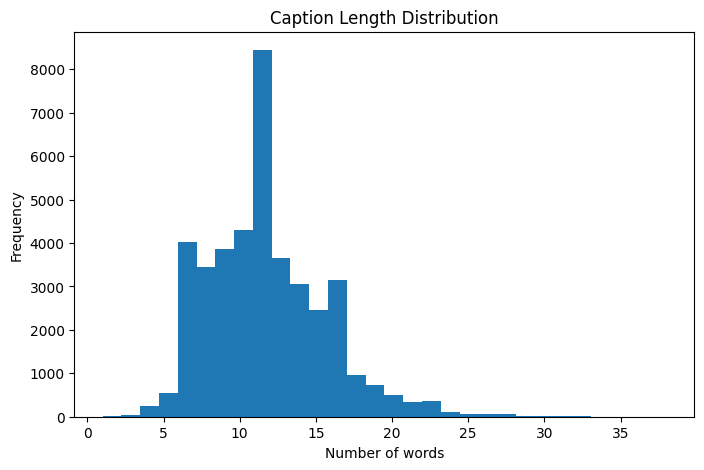

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df['word_count'], bins=30)
plt.title('Caption Length Distribution')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

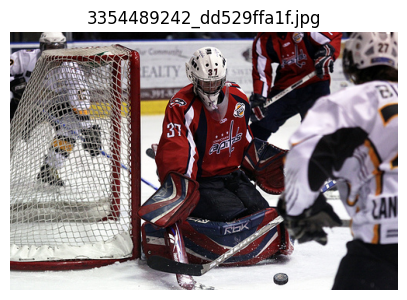

Captions:
- A goalie tries to block the puck in a hockey game .
- A hockey goalie stops the puck .
- People playing hockey .
- Several hockey players move toward the puck next to a goal .
- Two hockey teams compete .


In [7]:
# Show random image with its captions
random_image = random.choice(df['image'].unique())
img_path = os.path.join(images_path, random_image)

plt.figure(figsize=(5, 5))
plt.imshow(Image.open(img_path))
plt.axis('off')
plt.title(random_image)
plt.show()

print('Captions:')
for cap in df[df['image'] == random_image]['caption'].values:
    print('-', cap)

## Week 2: Preprocessing + Baseline

Steps:
- clean captions
- add `<start>` and `<end>` tokens
- build vocabulary
- split train/validation/test
- extract image features using pretrained CNN
- train simple CNN-LSTM baseline

In [8]:
def clean_caption(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_caption'] = df['caption'].apply(clean_caption)
df['caption_tokens'] = df['clean_caption'].apply(lambda x: '<start> ' + x + ' <end>')

df[['image', 'caption', 'caption_tokens']].head()

,image,caption,caption_tokens
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,<start> a child in a pink dress is climbing up...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,<start> a girl going into a wooden building <end>
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,<start> a little girl climbing into a wooden p...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,<start> a little girl climbing the stairs to h...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,<start> a little girl in a pink dress going in...


In [9]:
unique_images = df['image'].unique()

train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.20, random_state=SEED)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=SEED)

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df = df[df['image'].isin(test_imgs)].reset_index(drop=True)

print('Train images:', len(train_imgs), 'captions:', len(train_df))
print('Val images:', len(val_imgs), 'captions:', len(val_df))
print('Test images:', len(test_imgs), 'captions:', len(test_df))

Train images: 6472 captions: 32360
Val images: 809 captions: 4045
Test images: 810 captions: 4050


In [10]:
MIN_FREQ = 2
counter = Counter()
for caption in train_df['caption_tokens']:
    counter.update(caption.split())

special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
words = [word for word, count in counter.items() if count >= MIN_FREQ and word not in special_tokens]

itos = special_tokens + sorted(words)
stoi = {word: idx for idx, word in enumerate(itos)}

PAD_IDX = stoi['<pad>']
START_IDX = stoi['<start>']
END_IDX = stoi['<end>']
UNK_IDX = stoi['<unk>']

vocab_size = len(itos)
print('Vocabulary size:', vocab_size)

def encode_caption(caption):
    return [stoi.get(token, UNK_IDX) for token in caption.split()]

for split_df in [train_df, val_df, test_df]:
    split_df['encoded'] = split_df['caption_tokens'].apply(encode_caption)

Vocabulary size: 4721


In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def build_feature_extractor(encoder_name):
    encoder_name = encoder_name.lower()

    if encoder_name == 'vgg16':
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)
        cnn = model.features
        avgpool = model.avgpool
        classifier_part = nn.Sequential(*list(model.classifier.children())[:-1])

        class VGGFeatureExtractor(nn.Module):
            def __init__(self, cnn, avgpool, classifier_part):
                super().__init__()
                self.cnn = cnn
                self.avgpool = avgpool
                self.classifier_part = classifier_part
            def forward(self, x):
                x = self.cnn(x)
                x = self.avgpool(x)
                x = torch.flatten(x, 1)
                x = self.classifier_part(x)
                return x

        feature_extractor = VGGFeatureExtractor(cnn, avgpool, classifier_part)
        feature_dim = 4096

    elif encoder_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        feature_extractor = nn.Sequential(*list(model.children())[:-1])
        feature_dim = 2048

    else:
        raise ValueError("encoder_name must be 'vgg16' or 'resnet50'")

    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()
    for p in feature_extractor.parameters():
        p.requires_grad = False

    return feature_extractor, feature_dim


def extract_features(image_names, encoder_name='resnet50', batch_size=64, save_dir='features'):
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'image_features_{encoder_name}.pt')

    if os.path.exists(save_path):
        print('Loading saved features:', save_path)
        return torch.load(save_path, map_location='cpu')

    feature_extractor, feature_dim = build_feature_extractor(encoder_name)
    features = {}
    image_names = list(image_names)

    for i in tqdm(range(0, len(image_names), batch_size)):
        batch_names = image_names[i:i + batch_size]
        images = []
        valid_names = []

        for image_name in batch_names:
            img_path = os.path.join(images_path, image_name)
            if not os.path.exists(img_path):
                continue
            image = Image.open(img_path).convert('RGB')
            images.append(transform(image))
            valid_names.append(image_name)

        if len(images) == 0:
            continue

        images = torch.stack(images).to(device)

        with torch.no_grad():
            batch_features = feature_extractor(images)
            batch_features = batch_features.view(batch_features.size(0), -1).cpu()

        for image_name, feature in zip(valid_names, batch_features):
            features[image_name] = feature

    torch.save(features, save_path)
    print('Saved features:', save_path)
    print('Feature dimension:', feature_dim)
    print('Extracted features:', len(features))
    return features

In [12]:
all_images = df['image'].unique()

# Week 2 baseline features
vgg16_features = extract_features(all_images, encoder_name='vgg16', batch_size=32)

# Week 3 improved encoder features
resnet50_features = extract_features(all_images, encoder_name='resnet50', batch_size=64)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.6MB/s]


  0%|          | 0/253 [00:00<?, ?it/s]

Saved features: features/image_features_vgg16.pt
Feature dimension: 4096
Extracted features: 8091
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


  0%|          | 0/127 [00:00<?, ?it/s]

Saved features: features/image_features_resnet50.pt
Feature dimension: 2048
Extracted features: 8091


In [13]:
class CaptionDataset(Dataset):
    def __init__(self, dataframe, image_features):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_features = image_features

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_name = row['image']
        feature = self.image_features[image_name]
        caption = torch.tensor(row['encoded'], dtype=torch.long)
        return feature, caption


def collate_fn(batch):
    features, captions = zip(*batch)
    features = torch.stack(features)
    lengths = [len(c) for c in captions]
    max_len = max(lengths)

    padded = torch.full((len(captions), max_len), PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap

    return features, padded


class CNNLSTMCaptioner(nn.Module):
    def __init__(self, vocab_size, feature_dim, embed_dim=256, hidden_dim=512, pad_idx=0, dropout=0.0):
        super().__init__()
        self.feature_proj = nn.Linear(feature_dim, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        caption_input = captions[:, :-1]
        img_embed = self.dropout(self.feature_proj(features)).unsqueeze(1)
        word_embed = self.dropout(self.embedding(caption_input))
        lstm_input = torch.cat([img_embed, word_embed], dim=1)
        output, _ = self.lstm(lstm_input)
        output = self.dropout(output)
        logits = self.fc(output)
        return logits

In [14]:
def train_one_model(model_name, image_features, feature_dim, lr=1e-3, batch_size=64, dropout=0.0, epochs=5):
    train_loader = DataLoader(
        CaptionDataset(train_df, image_features),
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        CaptionDataset(val_df, image_features),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    model = CNNLSTMCaptioner(
        vocab_size,
        feature_dim,
        dropout=dropout,
        pad_idx=PAD_IDX
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for features, captions in tqdm(train_loader, desc=f"{model_name} epoch {epoch}"):
            features = features.to(device)
            captions = captions.to(device)

            optimizer.zero_grad()

            # input: captions without last token
            inputs = captions[:, :-1]

            # target: captions without first token
            targets = captions[:, 1:]

            # model output
            logits = model(features, inputs)

            # make same sequence length
            min_len = min(logits.size(1), targets.size(1))
            logits = logits[:, :min_len, :]
            targets = targets[:, :min_len]

            loss = criterion(
                logits.reshape(-1, vocab_size),
                targets.reshape(-1)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for features, captions in val_loader:
                features = features.to(device)
                captions = captions.to(device)

                inputs = captions[:, :-1]
                targets = captions[:, 1:]

                logits = model(features, inputs)

                min_len = min(logits.size(1), targets.size(1))
                logits = logits[:, :min_len, :]
                targets = targets[:, :min_len]

                loss = criterion(
                    logits.reshape(-1, vocab_size),
                    targets.reshape(-1)
                )

                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": lr,
            "batch_size": batch_size,
            "dropout": dropout
        })

        print(
            f"{model_name} | Epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f}"
        )

    return model, pd.DataFrame(history)

## Week 3: Improve Model

Improvements:
- compare VGG16 encoder against ResNet50 encoder
- add dropout
- tune learning rate and batch size
- compare BLEU-1 and BLEU-2
- plot train/validation loss
- show good and bad examples

In [15]:
EPOCHS = 15

baseline_model, baseline_history = train_one_model(
    model_name='VGG16 + LSTM',
    image_features=vgg16_features,
    feature_dim=4096,
    lr=1e-3,
    batch_size=64,
    dropout=0.0,
    epochs=EPOCHS
)

improved_model, improved_history = train_one_model(
    model_name='ResNet50 + LSTM',
    image_features=resnet50_features,
    feature_dim=2048,
    lr=5e-4,
    batch_size=64,
    dropout=0.3,
    epochs=EPOCHS
)

history_df = pd.concat([baseline_history, improved_history], ignore_index=True)
history_df

VGG16 + LSTM epoch 1:   0%|          | 0/506 [00:00<?, ?it/s]

VGG16 + LSTM | Epoch 1/15 | train_loss=4.4844 | val_loss=4.0676


VGG16 + LSTM epoch 2:   0%|          | 0/506 [00:00<?, ?it/s]

VGG16 + LSTM | Epoch 2/15 | train_loss=3.8810 | val_loss=3.8103


VGG16 + LSTM epoch 3:   0%|          | 0/506 [00:00<?, ?it/s]

...

ResNet50 + LSTM epoch 14:   0%|          | 0/506 [00:00<?, ?it/s]

ResNet50 + LSTM | Epoch 14/15 | train_loss=2.9172 | val_loss=3.5401


ResNet50 + LSTM epoch 15:   0%|          | 0/506 [00:00<?, ?it/s]

ResNet50 + LSTM | Epoch 15/15 | train_loss=2.8709 | val_loss=3.5428


,model,epoch,train_loss,val_loss,learning_rate,batch_size,dropout
0,VGG16 + LSTM,1,4.484384,4.067650,0.0010,64,0.0
1,VGG16 + LSTM,2,3.880978,3.810343,0.0010,64,0.0
2,VGG16 + LSTM,3,3.584255,3.698120,0.0010,64,0.0
3,VGG16 + LSTM,4,3.367965,3.648799,0.0010,64,0.0
4,VGG16 + LSTM,5,3.183135,3.629967,0.0010,64,0.0
5,VGG16 + LSTM,6,3.015943,3.641133,0.0010,64,0.0
6,VGG16 + LSTM,7,2.856982,3.660744,0.0010,64,0.0
7,VGG16 + LSTM,8,2.701208,3.708169,0.0010,64,0.0
8,VGG16 + LSTM,9,2.554820,3.741668,0.0010,64,0.0
9,VGG16 + LSTM,10,2.415726,3.792126,0.0010,64,0.0


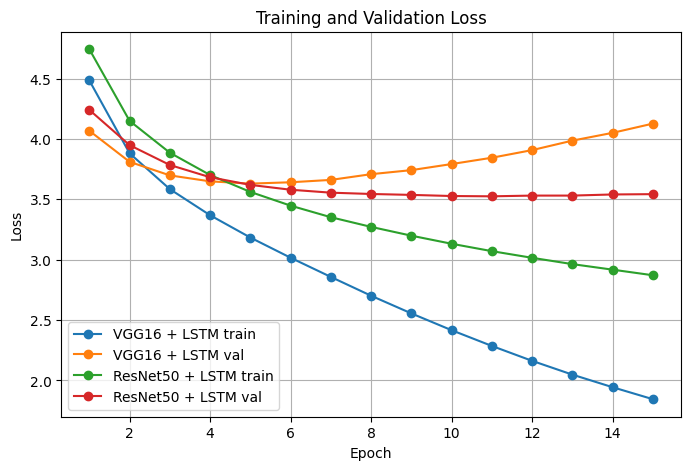

In [16]:
plt.figure(figsize=(8, 5))
for model_name in history_df['model'].unique():
    subset = history_df[history_df['model'] == model_name]
    plt.plot(subset['epoch'], subset['train_loss'], marker='o', label=f'{model_name} train')
    plt.plot(subset['epoch'], subset['val_loss'], marker='o', label=f'{model_name} val')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def generate_caption(model, feature, max_len=25):
    model.eval()
    generated = []
    input_word = torch.tensor([[START_IDX]], dtype=torch.long).to(device)
    feature = feature.unsqueeze(0).to(device)

    with torch.no_grad():
        img_embed = model.dropout(model.feature_proj(feature)).unsqueeze(1)
        output, hidden = model.lstm(img_embed)

        for _ in range(max_len):
            word_embed = model.embedding(input_word)
            output, hidden = model.lstm(word_embed, hidden)
            logits = model.fc(output.squeeze(1))
            predicted_idx = logits.argmax(dim=1).item()

            if predicted_idx == END_IDX:
                break

            predicted_word = itos[predicted_idx]
            if predicted_word not in ['<start>', '<pad>']:
                generated.append(predicted_word)

            input_word = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    return ' '.join(generated)


def evaluate_bleu(model, eval_df, image_features, max_images=None):
    references = []
    hypotheses = []

    grouped = eval_df.groupby('image')
    items = list(grouped)
    if max_images is not None:
        items = items[:max_images]

    for image_name, group in tqdm(items):
        if image_name not in image_features:
            continue
        refs = [cap.replace('<start>', '').replace('<end>', '').strip().split()
                for cap in group['caption_tokens'].values]
        pred = generate_caption(model, image_features[image_name]).split()
        if len(pred) == 0:
            pred = ['']
        references.append(refs)
        hypotheses.append(pred)

    smoothie = SmoothingFunction().method4
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    return bleu1, bleu2

baseline_bleu1, baseline_bleu2 = evaluate_bleu(baseline_model, test_df, vgg16_features)
improved_bleu1, improved_bleu2 = evaluate_bleu(improved_model, test_df, resnet50_features)

comparison_df = pd.DataFrame({
    'Model': ['VGG16 + LSTM', 'ResNet50 + LSTM'],
    'BLEU-1': [baseline_bleu1, improved_bleu1],
    'BLEU-2': [baseline_bleu2, improved_bleu2],
    'Notes': ['baseline', 'improved with dropout and tuned hyperparameters']
})
comparison_df

  0%|          | 0/810 [00:00<?, ?it/s]

  0%|          | 0/810 [00:00<?, ?it/s]

,Model,BLEU-1,BLEU-2,Notes
0,VGG16 + LSTM,0.398501,0.081922,baseline
1,ResNet50 + LSTM,0.444055,0.092893,improved with dropout and tuned hyperparameters


In [18]:
def collect_caption_examples(model, eval_df, image_features, max_images=100):
    rows = []
    grouped = list(eval_df.groupby('image'))[:max_images]
    smoothie = SmoothingFunction().method4

    for image_name, group in grouped:
        if image_name not in image_features:
            continue
        prediction = generate_caption(model, image_features[image_name])
        reference = group['clean_caption'].iloc[0]
        score = sentence_bleu([reference.split()], prediction.split(), weights=(1, 0, 0, 0), smoothing_function=smoothie)
        rows.append({'image': image_name, 'prediction': prediction, 'reference': reference, 'sentence_bleu1': score})

    return pd.DataFrame(rows).sort_values('sentence_bleu1', ascending=False)

examples_df = collect_caption_examples(improved_model, test_df, resnet50_features, max_images=150)
good_examples = examples_df.head(5)
bad_examples = examples_df.tail(5)

print('Good examples:')
display(good_examples)
print('Bad examples:')
display(bad_examples)

Good examples:


,image,prediction,reference,sentence_bleu1
14,1104133405_c04a00707f.jpg,boy a soccer in field a,a boy carrying a soccer ball,0.666667
85,1771490732_0ab5f029ac.jpg,boy soccer a soccer in field a,three boys playing soccer in a field,0.571429
148,2251747182_6b67a3ab8b.jpg,basketball in is a ball a,a boy playing basketball in a gym,0.564321
19,116409198_0fe0c94f3b.jpg,man a on in snow a,a man eats near a tent in the snow,0.505442
88,1794818900_e0ffdd268e.jpg,little in riding a on ride a,a girl plays on a red toy,0.428571


Bad examples:


,image,prediction,reference,sentence_bleu1
125,2141713971_e25eb12712.jpg,children in snow are on,a woman and a girl ride a sled down a hill sta...,0.0
128,2170222061_e8bce4a32d.jpg,brown white brown white black white brown blac...,a dog biting the tail of a cow,0.0
141,2230067846_74046b89d3.jpg,men a and in,children stretch outside,0.0
138,2206960564_325ed0c7ae.jpg,white with dog on leash in,a beige puppy walks across the floor,0.0
139,2220175999_081aa9cce8.jpg,dog through water a,two big dogs wade in the ocean,0.0


## Week 4: Streamlit App

The application lets a user upload an image and receive a generated caption from the improved ResNet50 + LSTM model.

This section saves the artifacts needed by `app.py`.

In [19]:
os.makedirs('artifacts', exist_ok=True)

# Save improved model
checkpoint = {
    'model_state_dict': improved_model.state_dict(),
    'feature_dim': 2048,
    'embed_dim': 256,
    'hidden_dim': 512,
    'dropout': 0.3,
    'vocab_size': vocab_size,
    'pad_idx': PAD_IDX,
    'start_idx': START_IDX,
    'end_idx': END_IDX,
    'unk_idx': UNK_IDX
}
torch.save(checkpoint, 'artifacts/resnet50_lstm_captioner.pt')

# Save vocabulary
with open('artifacts/vocab.json', 'w') as f:
    json.dump({'itos': itos, 'stoi': stoi}, f)

# Save results
os.makedirs('reports', exist_ok=True)
history_df.to_csv('reports/week3_training_history.csv', index=False)
comparison_df.to_csv('reports/week3_model_comparison.csv', index=False)
good_examples.to_csv('reports/week4_good_examples.csv', index=False)
bad_examples.to_csv('reports/week4_bad_examples.csv', index=False)

print('Saved model and project artifacts.')

Saved model and project artifacts.


## Discussion: Strengths and Limitations

**Strengths:** The project solves a meaningful multimodal problem, uses transfer learning with pretrained CNN encoders, compares baseline and improved methods, evaluates with BLEU, and provides an interactive app.

**Limitations:** The model may generate generic captions, may miss small objects, and uses greedy decoding. Future work could add attention, beam search, Transformer-based encoders/decoders, and larger datasets.